In [1]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pickle
import urllib.request
import zipfile
import os

Mounted at /content/drive


In [2]:
def load_glove_embeddings(glove_file_path, embedding_dim=100):
    embeddings_index = {}
    with open(glove_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

def create_embedding_matrix(tokenizer, embeddings_index, vocab_size, embedding_dim=100):
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    for word, i in tokenizer.word_index.items():
        if i < vocab_size:
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
    return embedding_matrix

def tokenize_and_pad(texts, tokenizer, max_len):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    return padded_sequences

def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def evaluate_model(y_true, y_pred, classes):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-averaged F1 Score: {f1:.4f}")
    plot_confusion_matrix(y_true, y_pred, classes)

In [13]:
# Text Normalization Function
def normalize_text(text, deep_mode=True):
    text = text.lower()

    # Replace common sensitive info and formats
    text = re.sub(r'\S+@\S+', ' <EMAIL> ', text)
    text = re.sub(r'http\S+|www\.\S+', ' <URL> ', text)
    text = re.sub(r'\b\d{1,2}/\d{1,2}/\d{2,4}\b', ' <DATE> ', text)
    text = re.sub(r'\b\d{1,2}:\d{2}(?:\s*[ap]m)?\b', ' <TIME> ', text)
    text = re.sub(r'\b\d+([\s\-.,/]+\d+)+\b', ' <NUMSEQ> ', text)
    text = re.sub(r'\b\d+\b', ' <NUM> ', text)

    # Remove common headers and metadata lines
    text = re.sub(r'^(content-|mime-|x-).*$','', text, flags=re.MULTILINE)
    text = re.sub(r'^\s*(from|to|cc|subject|sent|on|date):.*$', '', text, flags=re.MULTILINE)

    # Truncate long chains
    text = re.split(r'(forwarded by|-----original message-----|>+)', text, flags=re.IGNORECASE)[0]

    # Remove common placeholders or document references
    text = re.sub(r'<<.*?>>|\(see attached.*?\)|\.doc\b', ' ', text)

    # Remove phone number-like patterns
    text = re.sub(r'(phone|fax|mobile):?\s*\(?\d{2,}.*?\)?', '', text)

    # Remove long dashes and footers
    text = re.sub(r'[-]{2,}.*', '', text)

    # Remove specific pattern (cleaning location tags from signatures)
    text = re.sub(r'^[a-z .]+[\[\(]?\d{2,}.*?(houston|texas).*$', ' ', text, flags=re.MULTILINE)

    # Common email disclaimers
    text = re.sub(r'this e[-]?mail and any attachments.*?prohibited\.', ' ', text, flags=re.IGNORECASE | re.DOTALL)
    text = re.sub(r'i will be out of the office.*?(?=\n|$)', ' ', text, flags=re.IGNORECASE)

    # Trim email endings
    text = re.sub(r'\b(thanks|cheers|best|regards|talk to you|love)[,.\s]+\b.*$', '', text, flags=re.IGNORECASE)

    # Remove greetings like "Hi John"
    text = re.sub(r'\bhi\b[\s,]*[a-z]+\b', ' ', text)

    # Remove company-specific tokens
    text = re.sub(r'\benron\b|\bnorth america corp\b|\bect\b', ' ', text)

    # Collapse duplicate NUMSEQ tokens
    text = re.sub(r'(<NUMSEQ>\s*){2,}', ' <NUMSEQ> ', text)

    # Remove unwanted symbols
    text = re.sub(r'[^\w\s<>\.\?!]', ' ', text) if deep_mode else re.sub(r'[^\w\s<>]', ' ', text)

    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# Load dataset and filter
df = pd.read_csv(r"/content/drive/MyDrive/CAB420/ASSESSMENTS/ASSESSMENT_2/emails.csv")
print(f"Loaded {len(df)} emails.")

# Specify path to local GloVe file
glove_file = '/content/drive/MyDrive/CAB420/ASSESSMENTS/ASSESSMENT_2/glove.6B.300d.txt'

# Filter: only sent mail
df = df[df['message'].apply(lambda m: re.search(r'^X-Folder:\s*(.+)', m, re.MULTILINE | re.IGNORECASE) and 'sent' in re.search(r'^X-Folder:\s*(.+)', m, re.MULTILINE | re.IGNORECASE).group(1).lower())]

# Extract author from From: header
df['author'] = df['message'].apply(lambda m: re.search(r'^From:\s*(.+)', m, re.MULTILINE | re.IGNORECASE).group(1).strip().lower() if re.search(r'^From:\s*(.+)', m, re.MULTILINE | re.IGNORECASE) else None)

# Drop missing
df.dropna(subset=['message', 'author'], inplace=True)

# Limit message length
df = df[df['message'].str.len().between(50, 2000)]

# Keep top 20 authors
top_authors = df['author'].value_counts().nlargest(20).index
df = df[df['author'].isin(top_authors)].reset_index(drop=True)

# Robust email body extraction (skip header block)
def extract_body(msg):
    match = re.split(r'\n\s*\n', msg, maxsplit=1)
    return match[1].strip() if len(match) > 1 else msg.strip()

df['clean_text'] = df['message'].apply(extract_body)

# Train/Val/Test split
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['author'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['author'], random_state=42)

# Normalize text and drop short messages
for split in [train_df, val_df, test_df]:
    split['clean_text'] = split['clean_text'].apply(lambda x: normalize_text(x, deep_mode=True))
    split.drop(split[split['clean_text'].str.len() <= 40].index, inplace=True)
    split.drop(split[split['clean_text'].str.split().str.len() <= 10].index, inplace=True)

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(train_df['author'])
y_val_enc = label_encoder.transform(val_df['author'])
y_test_enc = label_encoder.transform(test_df['author'])

# Save processed splits
train_df.to_csv("train_emails.csv", index=False)
val_df.to_csv("val_emails.csv", index=False)
test_df.to_csv("test_emails.csv", index=False)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)} saved.")

Loaded 517401 emails.
Train: 20455, Val: 4376, Test: 4389 saved.


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


639/640 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0673 - loss: 3.2055

640/640 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.0674 - loss: 3.2049 - val_accuracy: 0.2045 - val_loss: 2.5114 - learning_rate: 5.0000e-04
Epoch 2/50
639/640 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2189 - loss: 2.4426

640/640 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.2190 - loss: 2.4422 - val_accuracy: 0.3855 - val_loss: 1.9777 - learning_rate: 5.0000e-04
Epoch 3/50
638/640 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3797 - loss: 1.9996

640/640 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.3799 - loss: 1.9992 - val_accuracy: 0.5162 - val_loss: 1.6824 - learning_rate: 5.0000e-04
Epoch 4/50
639/640 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5513 - loss: 1.6058

640/640 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5513 - loss: 1.6057 - val_accuracy: 0.6090 - val_loss: 1.3933 - learning_rate: 5.0000e-04
Epoch 5/50
639/640 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6297 - loss: 1.3237

640/640 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.6297 - loss: 1.3236 - val_accuracy: 0.6513 - val_loss: 1.2847 - learning_rate: 5.0000e-04
Epoch 6/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6909 - loss: 1.1219

640/640 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.6909 - loss: 1.1219 - val_accuracy: 0.6723 - val_loss: 1.2552 - learning_rate: 5.0000e-04
Epoch 7/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.7393 - loss: 0.9792 - val_accuracy: 0.6936 - val_loss: 1.2634 - learning_rate: 5.0000e-04
Epoch 8/50
639/640 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7914 - loss: 0.7994

640/640 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.7915 - loss: 0.7994 - val_accuracy: 0.7313 - val_loss: 1.1658 - learning_rate: 5.0000e-04
Epoch 9/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.8214 - loss: 0.6999 - val_accuracy: 0.7441 - val_loss: 1.1846 - learning_rate: 5.0000e-04
Epoch 10/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.8505 - loss: 0.5994 - val_accuracy: 0.7580 - val_loss: 1.1826 - learning_rate: 5.0000e-04
Epoch 11/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.8813 - loss: 0.4961 - val_accuracy: 0.7742 - val_loss: 1.1783 - learning_rate: 2.5000e-04
Epoch 12/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 39s 30ms/step - accuracy: 0.8993 - loss: 0.4348 - val_accuracy: 0.7829 - val_loss: 1.2325 - learning_rate: 2.5000e-04
Epoch 13/50
640/640 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9236 - loss: 0.3588 - val_accuracy: 0.7893 - val_loss: 1.2501 - learning_rate: 1.2500e-04


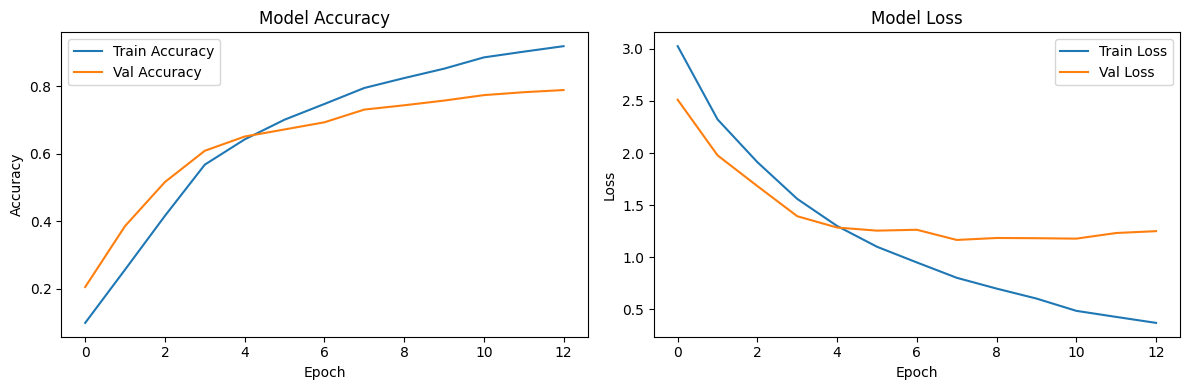

In [18]:
# Verify GloVe file exists
import os
if not os.path.exists(glove_file):
    raise FileNotFoundError(f"GloVe file {glove_file} not found in the working directory. Please upload it.")

# Load processed data
import pandas as pd
from sklearn.preprocessing import LabelEncoder
train_df = pd.read_csv('train_emails.csv')
val_df = pd.read_csv('val_emails.csv')
test_df = pd.read_csv('test_emails.csv')

# Encode labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['author'])
y_val = label_encoder.transform(val_df['author'])
y_test = label_encoder.transform(test_df['author'])

# Compute class weights for imbalanced classes
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Parameters
max_words = 5000  # Vocabulary size
max_len = 150     # Reduced to minimize padding noise
embedding_dim = 300  # For 300d GloVe
num_classes = len(label_encoder.classes_)

# Tokenize texts
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

def tokenize_and_pad(texts, tokenizer, max_len):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    return padded_sequences

X_train = tokenize_and_pad(train_df['clean_text'], tokenizer, max_len)
X_val = tokenize_and_pad(val_df['clean_text'], tokenizer, max_len)
X_test = tokenize_and_pad(test_df['clean_text'], tokenizer, max_len)

# Load GloVe embeddings
def load_glove_embeddings(glove_file_path, embedding_dim=300):
    embeddings_index = {}
    with open(glove_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

embeddings_index = load_glove_embeddings(glove_file, embedding_dim)

# Create embedding matrix
def create_embedding_matrix(tokenizer, embeddings_index, vocab_size, embedding_dim=300):
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    for word, i in tokenizer.word_index.items():
        if i < vocab_size:
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
    return embedding_matrix

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
embedding_matrix = create_embedding_matrix(tokenizer, embeddings_index, vocab_size, embedding_dim)

# Build Bidirectional LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
model = Sequential([
    Embedding(vocab_size, embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=True),
    Bidirectional(LSTM(96, return_sequences=True)),
    Dropout(0.5),  # Increased to prevent overfitting
    Bidirectional(LSTM(48)),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(0.002)),  # Reduced L2 regularization
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.002)),   # Reduced L2 regularization
    Dense(num_classes, activation='softmax')
])

# Compile model with custom learning rate
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_lstm_model.h5', monitor='val_loss', save_best_only=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=50,  # Increased to allow more training
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, checkpoint, lr_scheduler],
    class_weight=class_weight_dict
)

# Save tokenizer and label encoder
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
Validation Accuracy: 0.7331
Validation Macro-averaged F1 Score: 0.7173
Validation Total Inference Time: 5.19 seconds
Validation Average Inference Time per Sample: 0.0012 seconds

Test Accuracy: 0.7305
Test Macro-averaged F1 Score: 0.7111
Test Total Inference Time: 5.18 seconds
Test Average Inference Time per Sample: 0.0012 seconds



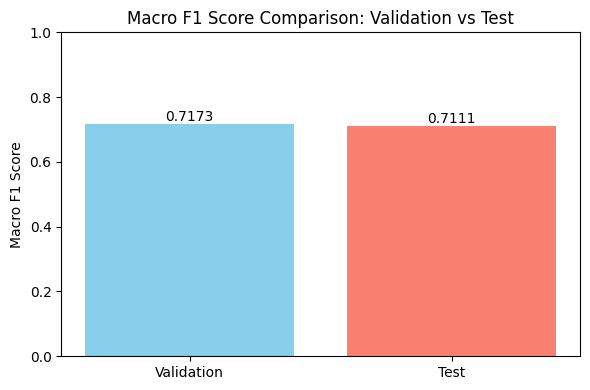

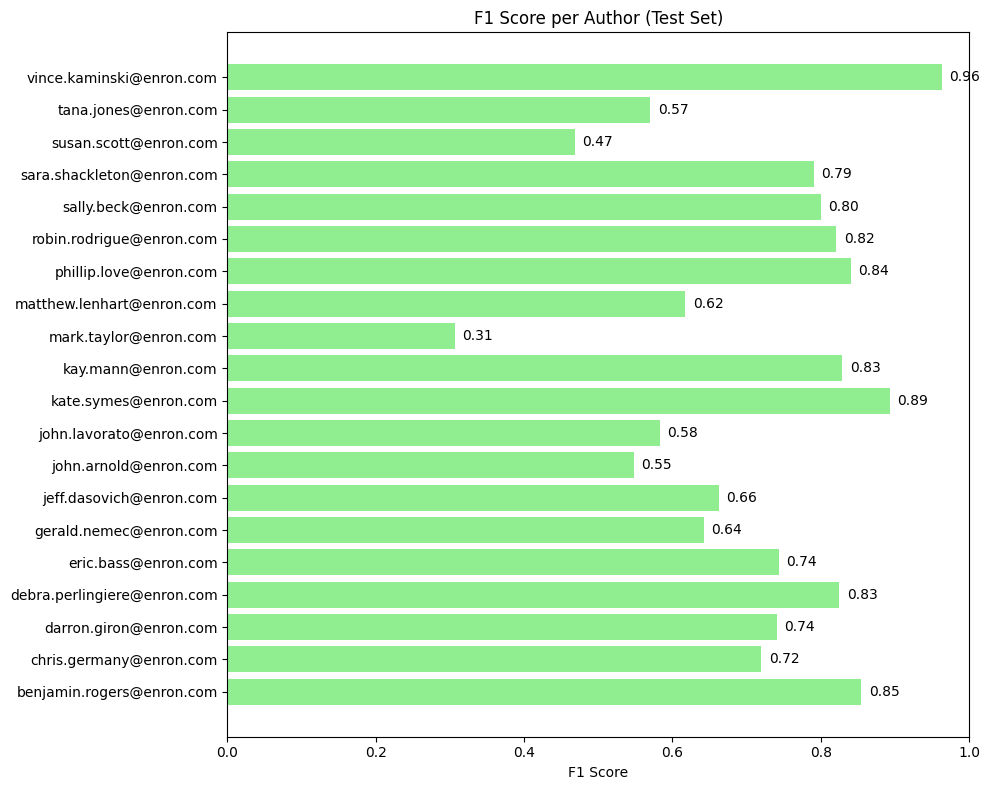

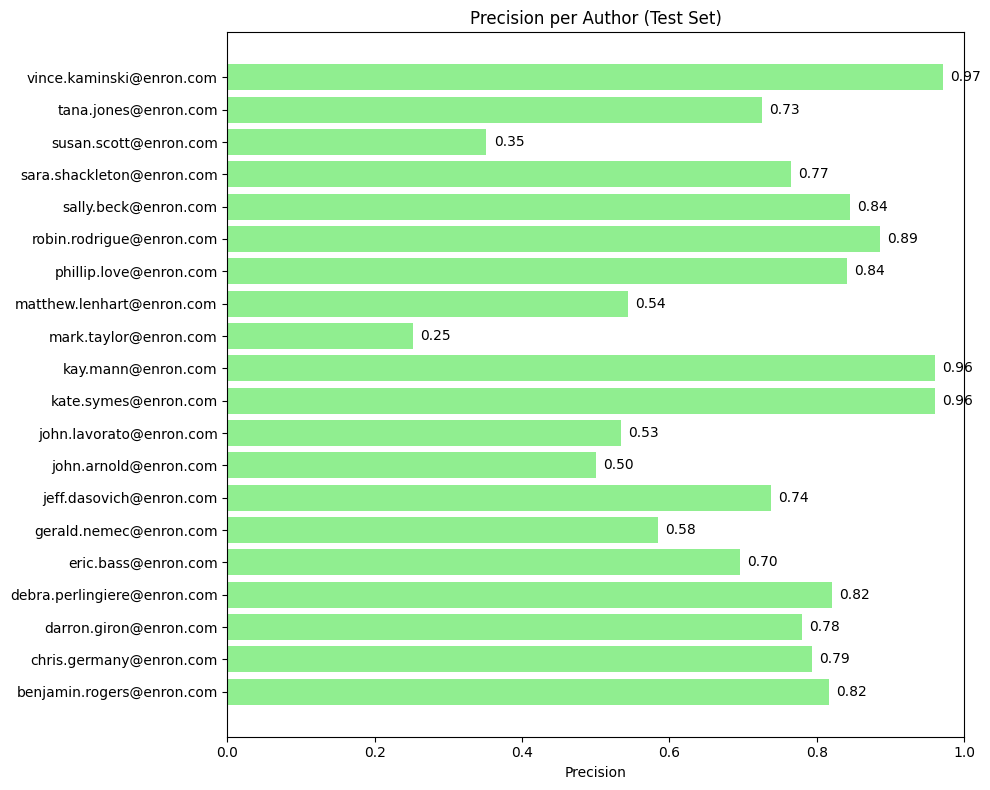

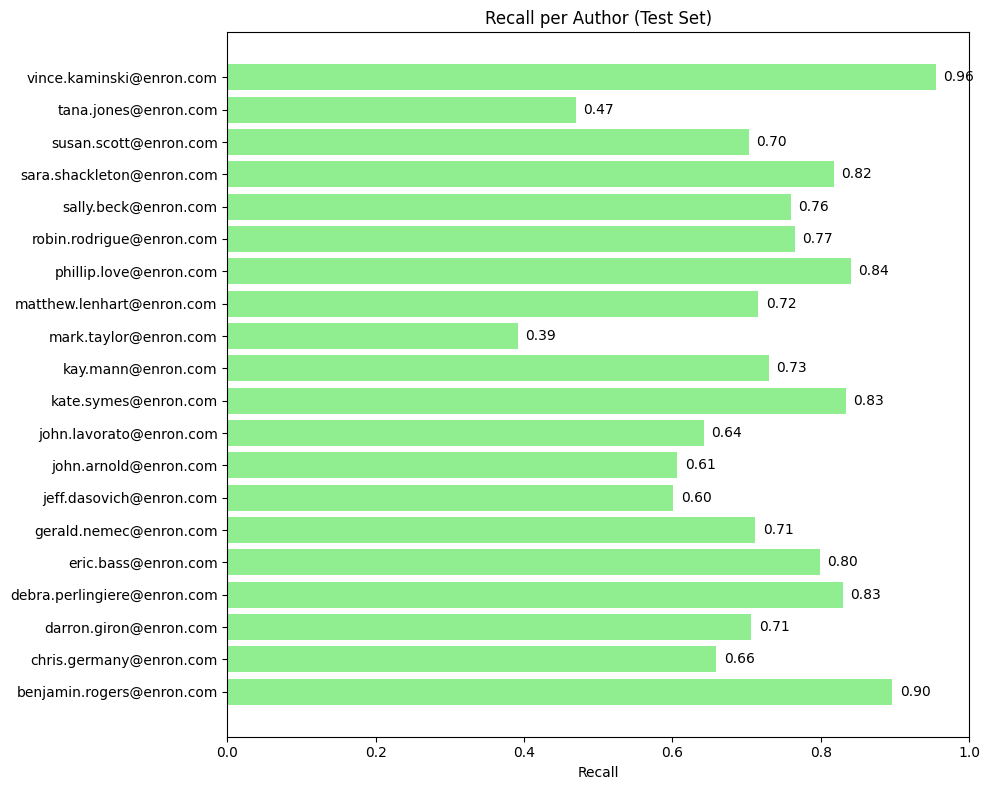

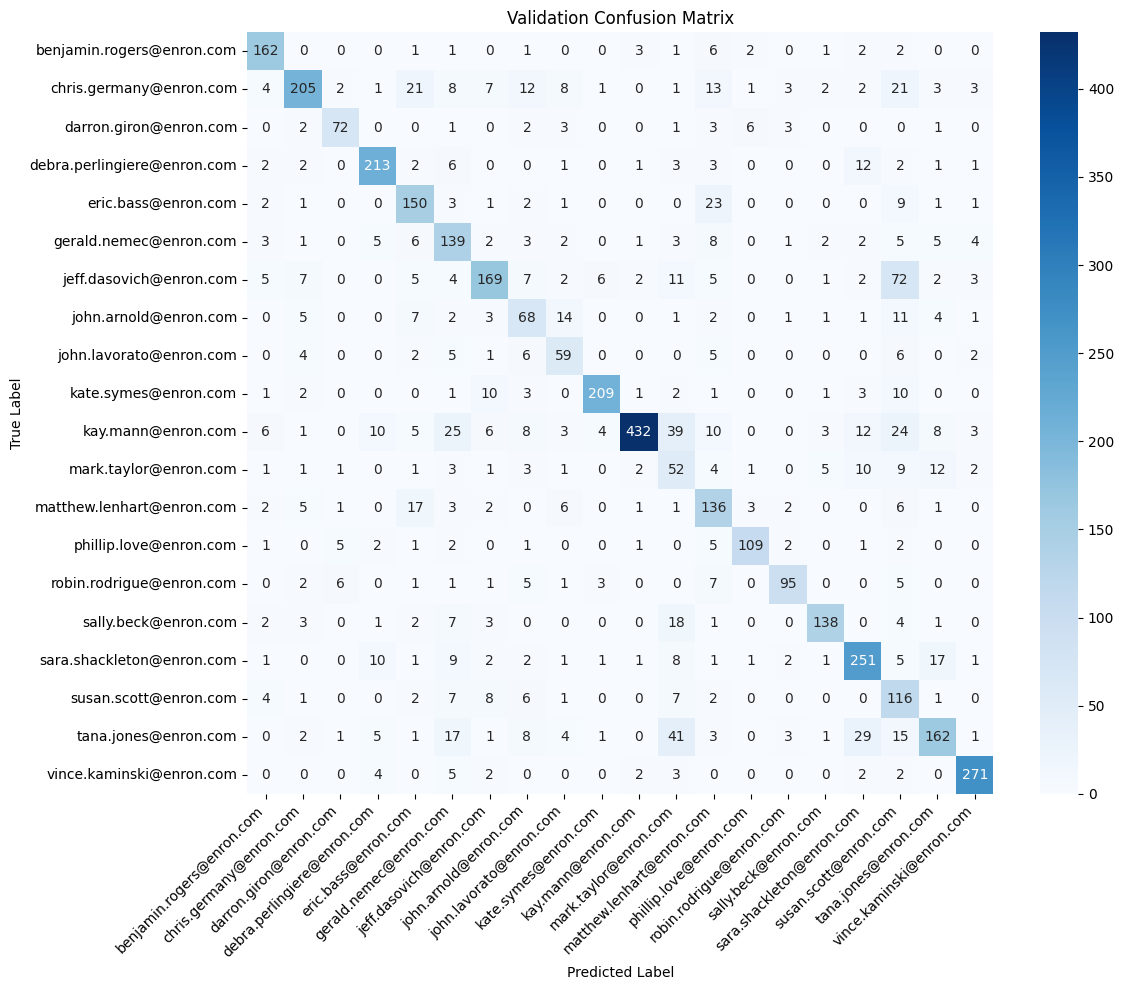

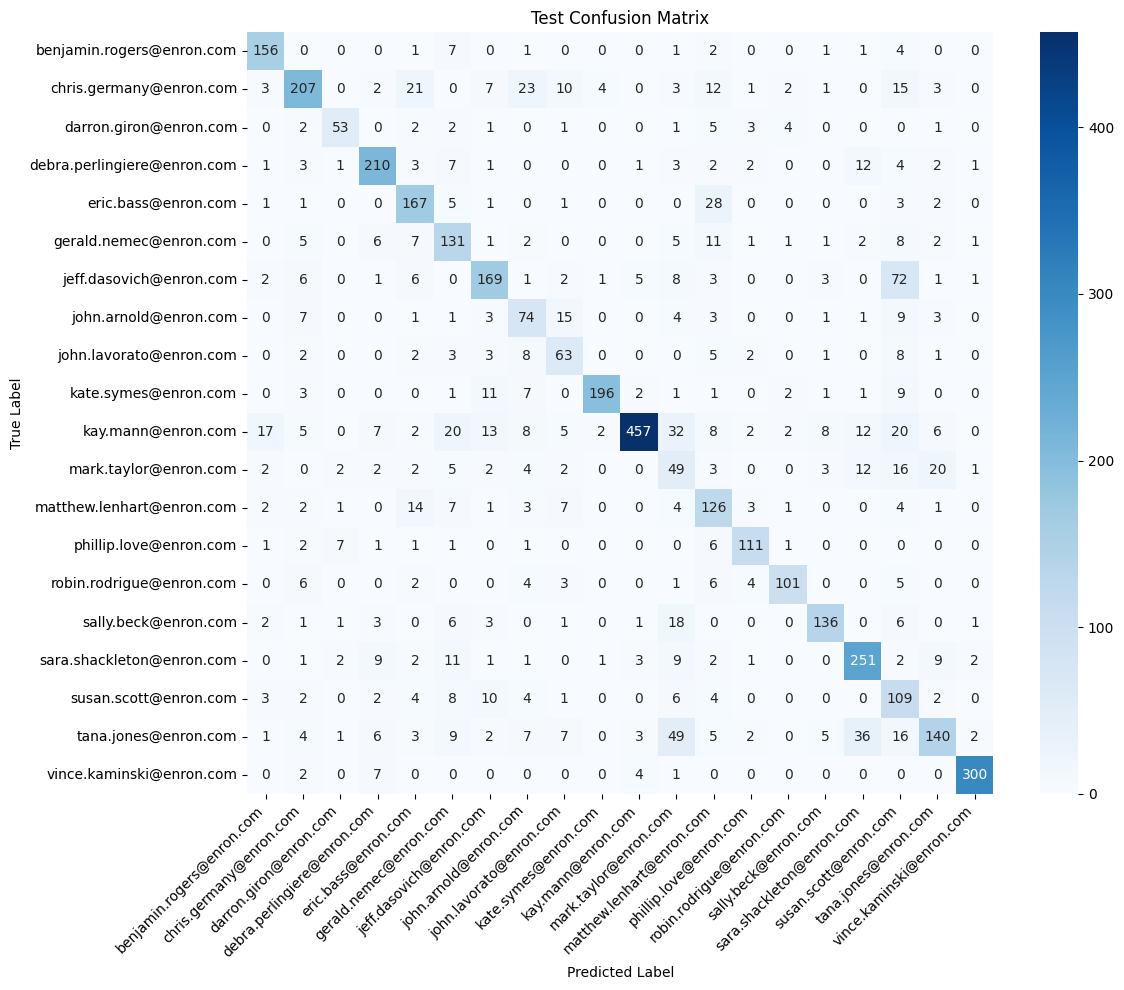

In [19]:
# Load processed validation and test data
import pandas as pd
val_df = pd.read_csv('val_emails.csv')
test_df = pd.read_csv('test_emails.csv')

# Load tokenizer and label encoder
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Prepare validation and test data
def tokenize_and_pad(texts, tokenizer, max_len=300):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
    return padded_sequences

X_val = tokenize_and_pad(val_df['clean_text'], tokenizer, max_len=300)
X_test = tokenize_and_pad(test_df['clean_text'], tokenizer, max_len=300)
y_val = label_encoder.transform(val_df['author'])
y_test = label_encoder.transform(test_df['author'])

# Load trained model
from tensorflow.keras.models import load_model
model = load_model('best_lstm_model.h5')

# Predict on validation and test sets with timing
import time
import tensorflow as tf
import numpy as np

# Validation predictions
start_time = time.time()
y_val_pred_probs = model.predict(X_val)
y_val_pred = np.argmax(y_val_pred_probs, axis=1)
val_inference_time = time.time() - start_time
val_avg_inference_time = val_inference_time / len(val_df)

# Test predictions
start_time = time.time()
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
test_inference_time = time.time() - start_time
test_avg_inference_time = test_inference_time / len(test_df)

# Evaluate metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def compute_metrics(y_true, y_pred, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{dataset_name} Accuracy: {acc:.4f}")
    print(f"{dataset_name} Macro-averaged F1 Score: {macro_f1:.4f}")
    return acc, macro_f1

def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_bar_comparison(val_f1, test_f1):
    plt.figure(figsize=(6, 4))
    datasets = ['Validation', 'Test']
    f1_scores = [val_f1, test_f1]
    plt.bar(datasets, f1_scores, color=['skyblue', 'salmon'])
    plt.title('Macro F1 Score Comparison: Validation vs Test')
    plt.ylabel('Macro F1 Score')
    plt.ylim(0, 1)
    for i, v in enumerate(f1_scores):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
    plt.tight_layout()
    plt.show()

def plot_side_bar_metrics(y_true, y_pred, classes, metric_name):
    # Map user-friendly metric names to classification_report keys
    metric_map = {
        'f1 score': 'f1-score',
        'precision': 'precision',
        'recall': 'recall'
    }
    report = classification_report(y_true, y_pred, output_dict=True, target_names=classes)
    metric_key = metric_map[metric_name.lower()]
    values = [report[c][metric_key] for c in classes]
    plt.figure(figsize=(10, 8))
    bars = plt.barh(classes, values, color='lightgreen')
    plt.title(f'{metric_name} per Author (Test Set)')
    plt.xlabel(metric_name)
    plt.xlim(0, 1)
    for bar, value in zip(bars, values):
        plt.text(value + 0.01, bar.get_y() + bar.get_height()/2, f'{value:.2f}', va='center')
    plt.tight_layout()
    plt.show()

# Compute and print validation metrics
val_acc, val_f1 = compute_metrics(y_val, y_val_pred, "Validation")
print(f"Validation Total Inference Time: {val_inference_time:.2f} seconds")
print(f"Validation Average Inference Time per Sample: {val_avg_inference_time:.4f} seconds\n")

# Compute and print test metrics
test_acc, test_f1 = compute_metrics(y_test, y_test_pred, "Test")
print(f"Test Total Inference Time: {test_inference_time:.2f} seconds")
print(f"Test Average Inference Time per Sample: {test_avg_inference_time:.4f} seconds\n")

# Plot Macro F1 Score comparison
plot_bar_comparison(val_f1, test_f1)

# Plot side bar graphs for test set metrics
classes = label_encoder.classes_
plot_side_bar_metrics(y_test, y_test_pred, classes, 'F1 Score')
plot_side_bar_metrics(y_test, y_test_pred, classes, 'Precision')
plot_side_bar_metrics(y_test, y_test_pred, classes, 'Recall')

# Plot confusion matrices
plot_confusion_matrix(y_val, y_val_pred, classes, 'Validation Confusion Matrix')
plot_confusion_matrix(y_test, y_test_pred, classes, 'Test Confusion Matrix')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/5
2557/2557 [==============================] - ETA: 0s - loss: 1.4099 - accuracy: 0.6130
Saved model at epoch 1 with val_loss: 0.8660
2557/2557 [==============================] - 285s 107ms/step - loss: 1.4099 - accuracy: 0.6130 - val_loss: 0.8660 - val_accuracy: 0.7507
Epoch 2/5
2557/2557 [==============================] - ETA: 0s - loss: 0.5737 - accuracy: 0.8374
Saved model at epoch 2 with val_loss: 0.6274
2557/2557 [==============================] - 271s 106ms/step - loss: 0.5737 - accuracy: 0.8374 - val_loss: 0.6274 - val_accuracy: 0.8220
Epoch 3/5
2557/2557 [==============================] - ETA: 0s - loss: 0.2601 - accuracy: 0.9322
Saved model at epoch 3 with val_loss: 0.5495
2557/2557 [==============================] - 272s 106ms/step - loss: 0.2601 - accuracy: 0.9322 - val_loss: 0.5495 - val_accuracy: 0.8519
Epoch 4/5
2557/2557 [==============================] - ETA: 0s - loss: 0.1224 - accuracy: 0.9708
Saved model at epoch 4 with val_loss: 0.5302
2557/2557 [==========

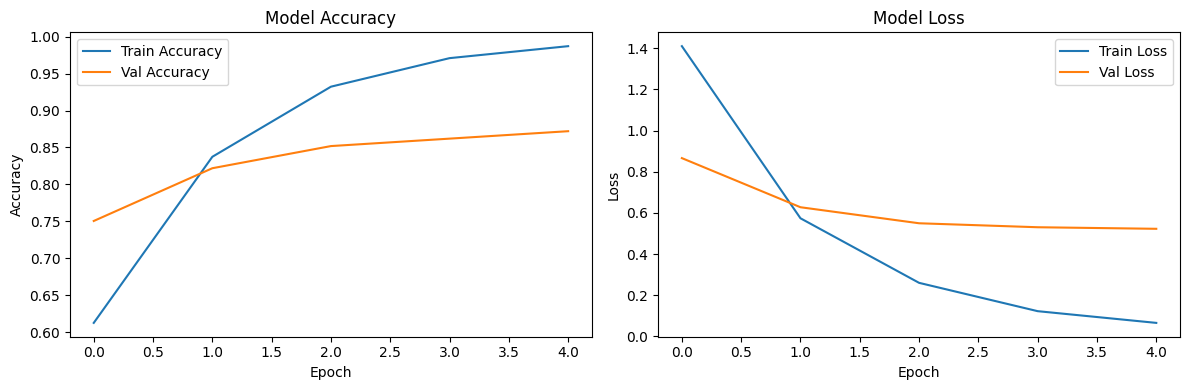

In [ ]:
# Install transformers library if not already installed
!pip install transformers

# Load processed data
import pandas as pd
from sklearn.preprocessing import LabelEncoder
train_df = pd.read_csv('train_emails.csv')
val_df = pd.read_csv('val_emails.csv')
test_df = pd.read_csv('test_emails.csv')

# Encode labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['author'])
y_val = label_encoder.transform(val_df['author'])
y_test = label_encoder.transform(test_df['author'])

# Compute class weights for imbalanced classes
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

# Parameters
max_len = 300  # Sequence length for DistilBERT
num_classes = len(label_encoder.classes_)
batch_size = 8  # Batch size for dataset
epochs = 5  # Fewer epochs for efficiency

# Tokenize texts with DistilBERT tokenizer
from transformers import DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_texts(texts, tokenizer, max_len):
    encodings = tokenizer(
        texts.tolist(),
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )
    return {'input_ids': encodings['input_ids'], 'attention_mask': encodings['attention_mask']}

train_encodings = tokenize_texts(train_df['clean_text'], tokenizer, max_len)
val_encodings = tokenize_texts(val_df['clean_text'], tokenizer, max_len)
test_encodings = tokenize_texts(test_df['clean_text'], tokenizer, max_len)

# Convert to tf.data.Dataset
import tensorflow as tf
train_dataset = tf.data.Dataset.from_tensor_slices((train_encodings, y_train)).batch(batch_size)
val_dataset = tf.data.Dataset.from_tensor_slices((val_encodings, y_val)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((test_encodings, y_test)).batch(batch_size)

# Build DistilBERT model
from transformers import TFDistilBertForSequenceClassification
model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_classes
)

# Compile model with transformers' AdamW optimizer
from transformers import create_optimizer
optimizer, _ = create_optimizer(
    init_lr=2e-5,
    num_train_steps=(len(train_df) // batch_size) * epochs,
    weight_decay_rate=0.01,
    num_warmup_steps=0
)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# Custom callback for class weights (placeholder, as direct support is limited)
class ClassWeightCallback(tf.keras.callbacks.Callback):
    def __init__(self, class_weight_dict):
        super().__init__()
        self.class_weight_dict = class_weight_dict

    def on_train_batch_begin(self, batch, logs=None):
        pass  # No direct batch weighting for transformers

    def _implements_train_batch_hooks(self):
        return False

    def _implements_test_batch_hooks(self):
        return False

    def _implements_predict_batch_hooks(self):
        return False

# Custom checkpoint callback for DistilBERT
class CustomCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, model, tokenizer, save_path):
        super().__init__()
        self._model = model
        self.tokenizer = tokenizer
        self.save_path = save_path
        self.best_val_loss = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss')
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self._model.save_pretrained(self.save_path)
            self.tokenizer.save_pretrained(self.save_path)
            print(f"\nSaved model at epoch {epoch + 1} with val_loss: {val_loss:.4f}")

    def _implements_train_batch_hooks(self):
        return False

    def _implements_test_batch_hooks(self):
        return False

    def _implements_predict_batch_hooks(self):
        return False

# Custom early stopping callback for DistilBERT
class CustomEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, model, save_path, patience=2, min_delta=0.0):
        super().__init__()
        self._model = model
        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_loss = float('inf')
        self.epochs_no_improve = 0
        self.best_weights_path = 'temp_best_model'

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss')
        if val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.epochs_no_improve = 0
            self._model.save_pretrained(self.best_weights_path)
        else:
            self.epochs_no_improve += 1
        if self.epochs_no_improve >= self.patience:
            print(f"\nEarly stopping triggered after epoch {epoch + 1}")
            self._model = TFDistilBertForSequenceClassification.from_pretrained(self.best_weights_path)
            self.model.stop_training = True

    def _implements_train_batch_hooks(self):
        return False

    def _implements_test_batch_hooks(self):
        return False

    def _implements_predict_batch_hooks(self):
        return False

# Callbacks
checkpoint = CustomCheckpoint(model, tokenizer, 'best_distilbert_model')
early_stopping = CustomEarlyStopping(model, 'best_distilbert_model', patience=2, min_delta=0.0)

# Train model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[checkpoint, early_stopping]
)

# Save model and tokenizer
model.save_pretrained('best_distilbert_model')
tokenizer.save_pretrained('best_distilbert_model')

# Save label encoder
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Some layers from the model checkpoint at best_distilbert_model were not used when initializing TFDistilBertForSequenceClassification: ['dropout_19']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at best_distilbert_model and are newly initialized: ['dropout_59']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


549/549 [==============================] - 15s 25ms/step
Accuracy: 0.8751
Macro-averaged F1 Score: 0.8602

Total Inference Time: 15.38 seconds
Average Inference Time per Sample: 0.0035 seconds


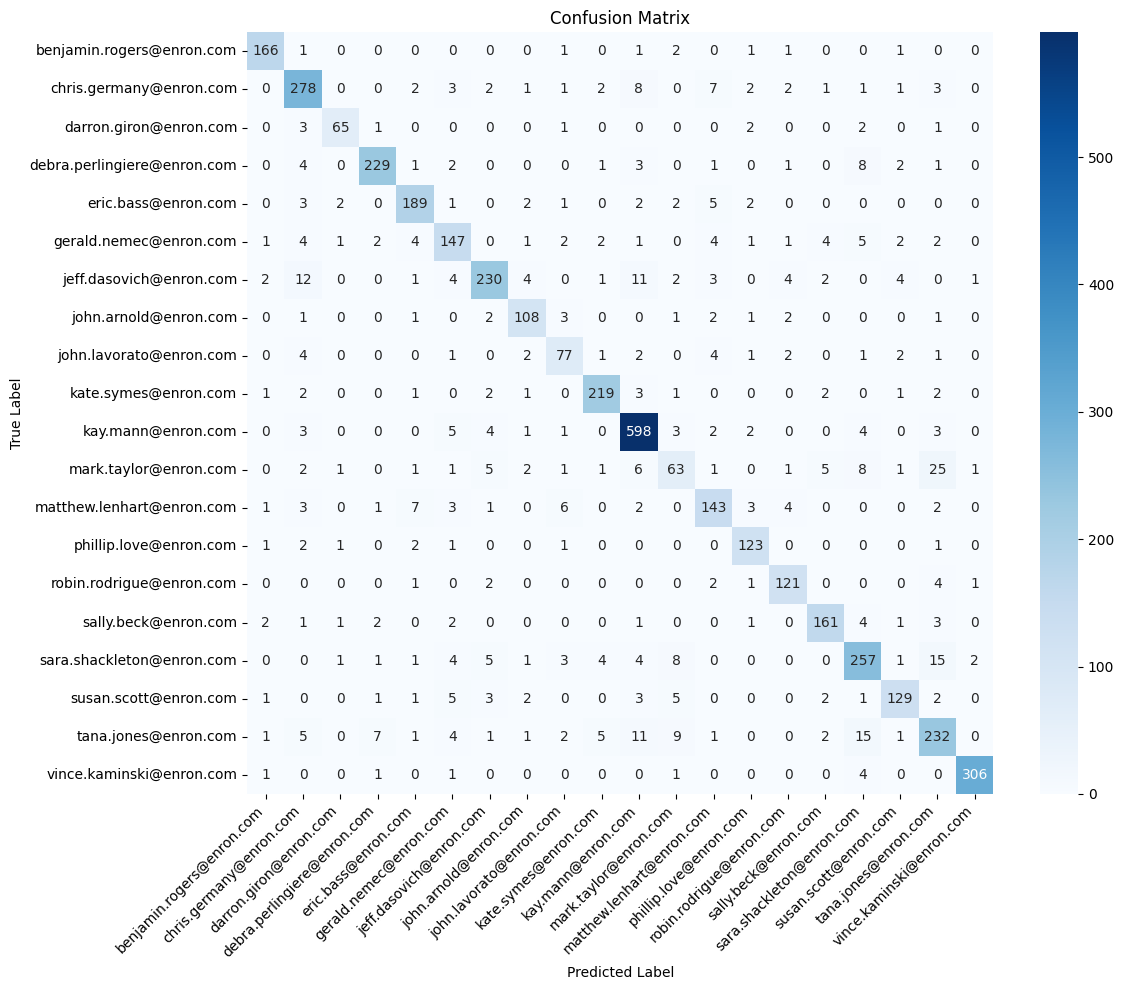


Per-class Metrics:
                             precision    recall  f1-score   support

  benjamin.rogers@enron.com       0.94      0.95      0.95       174
    chris.germany@enron.com       0.85      0.89      0.87       314
     darron.giron@enron.com       0.90      0.87      0.88        75
debra.perlingiere@enron.com       0.93      0.91      0.92       253
        eric.bass@enron.com       0.89      0.90      0.90       209
     gerald.nemec@enron.com       0.80      0.80      0.80       184
    jeff.dasovich@enron.com       0.89      0.82      0.86       281
      john.arnold@enron.com       0.86      0.89      0.87       122
    john.lavorato@enron.com       0.77      0.79      0.78        98
       kate.symes@enron.com       0.93      0.93      0.93       235
         kay.mann@enron.com       0.91      0.96      0.93       626
      mark.taylor@enron.com       0.65      0.50      0.57       125
  matthew.lenhart@enron.com       0.82      0.81      0.81       176
     phillip.

In [ ]:
# Load processed test data
import pandas as pd
test_df = pd.read_csv('test_emails.csv')

# Load tokenizer and label encoder
from transformers import DistilBertTokenizer
import pickle
tokenizer = DistilBertTokenizer.from_pretrained('best_distilbert_model')
with open('label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Prepare test data
def tokenize_texts(texts, tokenizer, max_len=300):
    encodings = tokenizer(
        texts.tolist(),
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )
    return {'input_ids': encodings['input_ids'], 'attention_mask': encodings['attention_mask']}

test_encodings = tokenize_texts(test_df['clean_text'], tokenizer, max_len=300)
y_test = label_encoder.transform(test_df['author'])

# Convert to tf.data.Dataset for inference
import tensorflow as tf
test_dataset = tf.data.Dataset.from_tensor_slices((test_encodings, y_test)).batch(8)

# Load trained model
from transformers import TFDistilBertForSequenceClassification
model = TFDistilBertForSequenceClassification.from_pretrained('best_distilbert_model')

# Predict on test set with timing
import time
start_time = time.time()
outputs = model.predict(test_dataset)
y_pred = tf.argmax(outputs.logits, axis=1).numpy()
inference_time = time.time() - start_time
avg_inference_time = inference_time / len(test_df)

# Evaluate metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def evaluate_model(y_true, y_pred, classes):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro-averaged F1 Score: {f1:.4f}")
    print(f"\nTotal Inference Time: {inference_time:.2f} seconds")
    print(f"Average Inference Time per Sample: {avg_inference_time:.4f} seconds")
    plot_confusion_matrix(y_true, y_pred, classes)

classes = label_encoder.classes_
evaluate_model(y_test, y_pred, classes)

# Per-class precision and recall
print("\nPer-class Metrics:")
print(classification_report(y_test, y_pred, target_names=classes))